# Imports and configs

In [1]:
# Core libraries
import os
import json
import joblib
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedGroupKFold, GroupKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, 
    accuracy_score, precision_recall_fscore_support,
    recall_score, precision_score
)

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.utils import Sequence, to_categorical, pad_sequences
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, add, MaxPooling1D, 
    Dropout, Bidirectional, LSTM, GRU, GlobalAveragePooling1D, 
    GlobalMaxPooling1D, Dense, Multiply, Reshape, Lambda, 
    Concatenate, GaussianNoise, SeparableConv1D, DepthwiseConv1D,
    LayerNormalization, MultiHeadAttention, Embedding
)
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, 
    LearningRateScheduler, CSVLogger
)
from tensorflow.keras.losses import (
    CategoricalCrossentropy, SparseCategoricalCrossentropy
)
from tensorflow.keras import backend as K

# Scientific computing
from scipy.spatial.transform import Rotation as R
from scipy import stats
from scipy.signal import find_peaks, periodogram
from scipy.fft import fft, fftfreq

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm


In [2]:
import random
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.experimental.numpy.random.seed(seed)
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
seed_everything(seed=42)

In [4]:
class DLConfig:
    seed = 42
    n_folds = 3
    
    # Model parameters
    batch_size = 64
    epochs = 160
    patience = 40
    lr_init = 5e-4
    weight_decay = 3e-3
    mixup_alpha = 0.4
    
    # Data parameters
    pad_percentile = 95
    
    # BFRB gesture mapping
    bfrb_gestures = [
        'Above ear - pull hair',
        'Cheek - pinch skin', 
        'Eyebrow - pull hair',
        'Eyelash - pull hair',
        'Forehead - pull hairline',
        'Forehead - scratch',
        'Neck - pinch skin',
        'Neck - scratch'
    ]

np.random.seed(DLConfig.seed)
tf.random.set_seed(DLConfig.seed)

print("▶ imports ready · tensorflow", tf.__version__)

▶ imports ready · tensorflow 2.19.0


In [5]:
class Config:
    train_path = "input/train.csv"
    train_demographic_path = "input/train_demographics.csv"
    test_path = "input/test.csv"
    test_demographic_path = "input/test_demographics.csv"

    target = "gesture"
    
    n_folds = 5
    seed = 42

    run_optuna = True
    n_optuna_trials = 100 

# Utility Functions

In [6]:
#Tensor Manipulations
def time_sum(x):
    return K.sum(x, axis=1)

def squeeze_last_axis(x):
    return tf.squeeze(x, axis=-1)

def expand_last_axis(x):
    return tf.expand_dims(x, axis=-1)

def se_block(x, reduction=8):
    ch = x.shape[-1]
    se = GlobalAveragePooling1D()(x)
    se = Dense(ch // reduction, activation='relu')(se)
    se = Dense(ch, activation='sigmoid')(se)
    se = Reshape((1, ch))(se)
    return Multiply()([x, se])

# Residual CNN Block with SE
def residual_se_cnn_block(x, filters, kernel_size, pool_size=2, drop=0.3, wd=1e-4):
    shortcut = x
    for _ in range(2):
        x = Conv1D(filters, kernel_size, padding='same', use_bias=False,
                   kernel_regularizer=l2(wd))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
    x = se_block(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same', use_bias=False,
                          kernel_regularizer=l2(wd))(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = add([x, shortcut])
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size)(x)
    x = Dropout(drop)(x)
    return x

def attention_layer(inputs):
    score = Dense(1, activation='tanh')(inputs)
    score = Lambda(squeeze_last_axis)(score)
    weights = Activation('softmax')(score)
    weights = Lambda(expand_last_axis)(weights)
    context = Multiply()([inputs, weights])
    context = Lambda(time_sum)(context)
    return context

# Feature engineering

In [7]:
class MixupGenerator(Sequence):
    def __init__(self, X, y, batch_size, alpha=0.2):
        self.X, self.y = X, y
        self.batch = batch_size
        self.alpha = alpha
        self.indices = np.arange(len(X))
    
    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch))
    
    def __getitem__(self, i):
        idx = self.indices[i*self.batch:(i+1)*self.batch]
        Xb, yb = self.X[idx], self.y[idx]
        lam = np.random.beta(self.alpha, self.alpha)
        perm = np.random.permutation(len(Xb))
        X_mix = lam * Xb + (1-lam) * Xb[perm]
        y_mix = lam * yb + (1-lam) * yb[perm]
        return X_mix, y_mix
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

In [8]:
def remove_gravity_from_acc(acc_data, rot_data) -> np.ndarray:

    if isinstance(acc_data, pd.DataFrame):
        acc_values = acc_data[['acc_x', 'acc_y', 'acc_z']].values
    else:
        acc_values = acc_data

    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = acc_values.shape[0]
    linear_accel = np.zeros_like(acc_values)
    
    gravity_world = np.array([0, 0, 9.81])

    for i in range(num_samples):
        if np.all(np.isnan(quat_values[i])) or np.all(np.isclose(quat_values[i], 0)):
            linear_accel[i, :] = acc_values[i, :] 
            continue

        try:
            rotation = R.from_quat(quat_values[i])
            gravity_sensor_frame = rotation.apply(gravity_world, inverse=True)
            linear_accel[i, :] = acc_values[i, :] - gravity_sensor_frame
        except ValueError:
             linear_accel[i, :] = acc_values[i, :]
             
    return linear_accel


def calculate_angular_velocity_from_quat(rot_data, time_delta=1/10) -> np.ndarray: # Assuming 10Hz sampling rate
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_vel = np.zeros((num_samples, 3))

    for i in range(num_samples - 1):
        q_t = quat_values[i]
        q_t_plus_dt = quat_values[i+1]

        if np.all(np.isnan(q_t)) or np.all(np.isclose(q_t, 0)) or \
           np.all(np.isnan(q_t_plus_dt)) or np.all(np.isclose(q_t_plus_dt, 0)):
            continue

        try:
            rot_t = R.from_quat(q_t)
            rot_t_plus_dt = R.from_quat(q_t_plus_dt)

            # Calculate the relative rotation
            delta_rot = rot_t.inv() * rot_t_plus_dt
            
            # Convert delta rotation to angular velocity vector
            # The rotation vector (Euler axis * angle) scaled by 1/dt
            # is a good approximation for small delta_rot
            angular_vel[i, :] = delta_rot.as_rotvec() / time_delta
        except ValueError:
            # If quaternion is invalid, angular velocity remains zero
            pass
            
    return angular_vel


def calculate_angular_distance(rot_data) -> np.ndarray:
    if isinstance(rot_data, pd.DataFrame):
        quat_values = rot_data[['rot_x', 'rot_y', 'rot_z', 'rot_w']].values
    else:
        quat_values = rot_data

    num_samples = quat_values.shape[0]
    angular_dist = np.zeros(num_samples)

    for i in range(num_samples - 1):
        q1 = quat_values[i]
        q2 = quat_values[i+1]

        if np.all(np.isnan(q1)) or np.all(np.isclose(q1, 0)) or \
           np.all(np.isnan(q2)) or np.all(np.isclose(q2, 0)):
            angular_dist[i] = 0 # Или np.nan, в зависимости от желаемого поведения
            continue
        try:
            # Преобразование кватернионов в объекты Rotation
            r1 = R.from_quat(q1)
            r2 = R.from_quat(q2)

            # Вычисление углового расстояния: 2 * arccos(|real(p * q*)|)
            # где p* - сопряженный кватернион q
            # В scipy.spatial.transform.Rotation, r1.inv() * r2 дает относительное вращение.
            # Угол этого относительного вращения - это и есть угловое расстояние.
            relative_rotation = r1.inv() * r2
            
            # Угол rotation vector соответствует угловому расстоянию
            # Норма rotation vector - это угол в радианах
            angle = np.linalg.norm(relative_rotation.as_rotvec())
            angular_dist[i] = angle
        except ValueError:
            angular_dist[i] = 0 # В случае недействительных кватернионов
            pass
            
    return angular_dist

In [9]:
def build_gesture_model(pad_len, imu_dim, extra_dim, n_classes, wd=1e-4):
    """
    Two-branch architecture similar to URL Notebook
    """
    inp = Input(shape=(pad_len, imu_dim + extra_dim))
    
    # Split into IMU and extra sensor branches
    imu = Lambda(lambda t: t[:, :, :imu_dim])(inp)
    extra = Lambda(lambda t: t[:, :, imu_dim:])(inp)

    # IMU deep branch (for precise temporal patterns)
    x1 = residual_se_cnn_block(imu, 64, 3, drop=0.1, wd=wd)
    x1 = residual_se_cnn_block(x1, 128, 5, drop=0.1, wd=wd)

    # Extra sensor lighter branch (for thermal/ToF)
    x2 = Conv1D(64, 3, padding='same', use_bias=False, kernel_regularizer=l2(wd))(extra)
    x2 = BatchNormalization()(x2)
    x2 = Activation('relu')(x2)
    x2 = MaxPooling1D(2)(x2)
    x2 = Dropout(0.2)(x2)
    
    x2 = Conv1D(128, 3, padding='same', use_bias=False, kernel_regularizer=l2(wd))(x2)
    x2 = BatchNormalization()(x2)
    x2 = Activation('relu')(x2)
    x2 = MaxPooling1D(2)(x2)
    x2 = Dropout(0.2)(x2)

    # Merge branches
    merged = Concatenate()([x1, x2])

    # RNN layers
    xa = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(wd)))(merged)
    xb = Bidirectional(GRU(128, return_sequences=True, kernel_regularizer=l2(wd)))(merged)
    xc = GaussianNoise(0.09)(merged)
    xc = Dense(16, activation='elu')(xc)
    
    # Concatenate and apply attention
    x = Concatenate()([xa, xb, xc])
    x = Dropout(0.4)(x)
    x = attention_layer(x)

    # Classification head
    for units, drop in [(256, 0.5), (128, 0.3)]:
        x = Dense(units, use_bias=False, kernel_regularizer=l2(wd))(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(drop)(x)

    output = Dense(n_classes, activation='softmax', kernel_regularizer=l2(wd))(x)
    
    model = Model(inp, output)
    return model

In [10]:
def create_imu_features(df):
    """
    Create imu features
    """
    features_df = df.copy()
    
    # Basic engineered features
    features_df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)
    features_df['rot_angle'] = 2 * np.arccos(df['rot_w'].clip(-1, 1))
    
    # Derivatives
    features_df['acc_mag_jerk'] = features_df.groupby('sequence_id')['acc_mag'].diff().fillna(0)
    features_df['rot_angle_vel'] = features_df.groupby('sequence_id')['rot_angle'].diff().fillna(0)
    
    # Linear acceleration (gravity removal)
    linear_accel_list = []
    for seq_id, group in features_df.groupby('sequence_id'):
        acc_data = group[['acc_x', 'acc_y', 'acc_z']]
        rot_data = group[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
        linear_accel = remove_gravity_from_acc(acc_data, rot_data)  # Use existing function
        linear_accel_df = pd.DataFrame(
            linear_accel, 
            columns=['linear_acc_x', 'linear_acc_y', 'linear_acc_z'], 
            index=group.index
        )
        linear_accel_list.append(linear_accel_df)
    
    linear_accel_combined = pd.concat(linear_accel_list)
    features_df = pd.concat([features_df, linear_accel_combined], axis=1)
    
    # Linear acceleration magnitude and derivatives
    features_df['linear_acc_mag'] = np.sqrt(
        features_df['linear_acc_x']**2 + 
        features_df['linear_acc_y']**2 + 
        features_df['linear_acc_z']**2
    )
    features_df['linear_acc_mag_jerk'] = features_df.groupby('sequence_id')['linear_acc_mag'].diff().fillna(0)
    
    # Angular velocity from quaternions
    angular_vel_list = []
    for seq_id, group in features_df.groupby('sequence_id'):
        rot_data = group[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
        angular_vel = calculate_angular_velocity_from_quat(rot_data, time_delta=1/10)  # Use existing function
        angular_vel_df = pd.DataFrame(
            angular_vel,
            columns=['angular_vel_x', 'angular_vel_y', 'angular_vel_z'],
            index=group.index
        )
        angular_vel_list.append(angular_vel_df)
    
    angular_vel_combined = pd.concat(angular_vel_list)
    features_df = pd.concat([features_df, angular_vel_combined], axis=1)
    
    # Angular distance
    angular_dist_list = []
    for seq_id, group in features_df.groupby('sequence_id'):
        rot_data = group[['rot_x', 'rot_y', 'rot_z', 'rot_w']]
        angular_dist = calculate_angular_distance(rot_data)  # Use existing function
        angular_dist_df = pd.DataFrame(
            angular_dist,
            columns=['angular_distance'],
            index=group.index
        )
        angular_dist_list.append(angular_dist_df)
    
    angular_dist_combined = pd.concat(angular_dist_list)
    features_df = pd.concat([features_df, angular_dist_combined], axis=1)
    
    return features_df

def prepare_sequences_for_dl(df, config, label_column='e_gesture'):
    """
    Prepare sequences for deep learning training
    """
    print("Creating features...")
    df_features = create_imu_features(df)
    
    # Define feature columns (similar to URL Notebook)
    imu_base_cols = ['linear_acc_x', 'linear_acc_y', 'linear_acc_z', 
                     'rot_x', 'rot_y', 'rot_z', 'rot_w']
    
    imu_engineered_cols = [
        'acc_mag', 'rot_angle', 'acc_mag_jerk', 'rot_angle_vel',
        'linear_acc_mag', 'linear_acc_mag_jerk',
        'angular_vel_x', 'angular_vel_y', 'angular_vel_z',
        'angular_distance'
    ]
    
    imu_cols = imu_base_cols + imu_engineered_cols
    
    # Thermal columns
    thm_cols = [f'thm_{i}' for i in range(1, 6)]
    
    # ToF aggregated features
    tof_agg_cols = []
    for i in range(1, 6):
        tof_agg_cols.extend([f'tof_{i}_mean', f'tof_{i}_std', f'tof_{i}_min', f'tof_{i}_max'])
    
    # Build sequences
    X_list, y_list, seq_ids = [], [], []
    
    print("Building sequences...")
    for seq_id, seq_df in tqdm(df_features.groupby('sequence_id'), desc="Processing sequences"):
        # Create ToF aggregated features
        for i in range(1, 6):
            pixel_cols = [f"tof_{i}_v{p}" for p in range(64)]
            if all(col in seq_df.columns for col in pixel_cols):
                tof_data = seq_df[pixel_cols].replace(-1, np.nan)
                seq_df[f'tof_{i}_mean'] = tof_data.mean(axis=1)
                seq_df[f'tof_{i}_std'] = tof_data.std(axis=1)
                seq_df[f'tof_{i}_min'] = tof_data.min(axis=1)
                seq_df[f'tof_{i}_max'] = tof_data.max(axis=1)
            else:
                seq_df[f'tof_{i}_mean'] = 0
                seq_df[f'tof_{i}_std'] = 0
                seq_df[f'tof_{i}_min'] = 0
                seq_df[f'tof_{i}_max'] = 0
        
        # Combine all features
        all_feature_cols = imu_cols + thm_cols + tof_agg_cols
        feature_matrix = seq_df[all_feature_cols].fillna(0).values.astype('float32')
        
        X_list.append(feature_matrix)
        y_list.append(seq_df[label_column].iloc[0])  # Gesture label
        seq_ids.append(seq_id)
    
    return X_list, np.array(y_list), np.array(seq_ids), len(imu_cols), len(thm_cols + tof_agg_cols)


# Training & Validation

In [11]:
CONFUSION_PAIRS = {
    # 顔周りのジェスチャー（BFRB）の混同
    'Above ear - pull hair': ['Eyelash - pull hair', 'Forehead - pull hairline', 'Neck - pinch skin'],
    'Cheek - pinch skin': ['Above ear - pull hair', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Neck - pinch skin'],
    'Eyebrow - pull hair': ['Cheek - pinch skin', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Neck - pinch skin'],
    'Eyelash - pull hair': ['Cheek - pinch skin', 'Eyebrow - pull hair', 'Forehead - pull hairline', 'Neck - pinch skin'],
    'Forehead - pull hairline': ['Forehead - scratch', 'Neck - pinch skin'],
    'Forehead - scratch': ['Forehead - pull hairline'],
    'Neck - pinch skin': ['Above ear - pull hair', 'Neck - scratch', 'Forehead - pull hairline'],
    'Neck - scratch': ['Neck - pinch skin'],
    
    # 脚・膝周りのジェスチャーの混同
    'Pinch knee/leg skin': ['Pull air toward your face', 'Scratch knee/leg skin', 'Write name on leg'],
    'Scratch knee/leg skin': ['Pinch knee/leg skin', 'Pull air toward your face', 'Write name on leg'],
    'Write name on leg': ['Pinch knee/leg skin', 'Scratch knee/leg skin'],
    
    # その他の混同
    'Write name in air': ['Write name on leg'],
    'Pull air toward your face': ['Pinch knee/leg skin', 'Scratch knee/leg skin']
}

SMOOTHING_STRENGTHS = {
    # 高混同クラス（強いスムージング: 0.15）
    'high_confusion': [
        'Cheek - pinch skin',      # 5つのクラスと混同
        'Eyebrow - pull hair',     # 4つのクラスと混同
        'Eyelash - pull hair',     # 4つのクラスと混同
        'Pinch knee/leg skin',     # 3つのクラスと混同
        'Scratch knee/leg skin',   # 3つのクラスと混同
        'Neck - pinch skin',       # 3つのクラスと混同
        'Pull air toward your face' # 2つのクラスと混同
    ],
    # 中程度混同クラス（中程度スムージング: 0.12）
    'medium_confusion': [
        'Above ear - pull hair',   # 3つのクラスと混同
        'Forehead - pull hairline', # 2つのクラスと混同
        'Write name on leg',       # 2つのクラスと混同
        'Neck - scratch'           # 1つのクラスと混同
    ]
}

SMOOTHING_VALUES = {
    'high_confusion': 0.15,    # 強いスムージング
    'medium_confusion': 0.12,  # 中程度のスムージング
    'default': 0.1             # 基本スムージング
}

def get_smoothing_strengths(class_names):
    """
    クラスごとのスムージング強度を取得
    """
    smoothing_strengths = {}
    
    for class_name in class_names:
        if class_name in SMOOTHING_STRENGTHS['high_confusion']:
            smoothing_strengths[class_name] = SMOOTHING_VALUES['high_confusion']
        elif class_name in SMOOTHING_STRENGTHS['medium_confusion']:
            smoothing_strengths[class_name] = SMOOTHING_VALUES['medium_confusion']
        else:
            smoothing_strengths[class_name] = SMOOTHING_VALUES['default']
                
    return smoothing_strengths

In [16]:
def create_class_dependent_smoothing_matrix(class_names, alpha=0.1):
    """
    クラス依存のスムージング行列を作成
    """
    # class_namesを確実にリストに変換
    class_names = list(class_names)
    n_classes = len(class_names)
    smoothing_strengths = get_smoothing_strengths(class_names)
    
    smoothing_matrix = np.eye(n_classes) * (1 - alpha)
    
    for i, class_name in enumerate(class_names):
        if class_name in CONFUSION_PAIRS:
            # 混同しやすいクラスを特定
            confused_classes = CONFUSION_PAIRS[class_name]
            
            # 混同クラスのインデックスを取得
            confused_indices = []
            for confused_class in confused_classes:
                if confused_class in class_names:
                    confused_indices.append(class_names.index(confused_class))
            
            if confused_indices:
                # スムージング強度を取得
                smoothing_strength = smoothing_strengths.get(class_name, alpha)
                
                # 混同クラス間でスムージングを分配
                smoothing_per_class = smoothing_strength / len(confused_indices)
                
                # 対角線要素を調整
                smoothing_matrix[i, i] = 1 - smoothing_strength
                
                # 混同クラスにスムージングを適用
                for confused_idx in confused_indices:
                    smoothing_matrix[i, confused_idx] = smoothing_per_class
    
    return smoothing_matrix


def apply_class_dependent_smoothing(y_true, class_names, alpha=0.1):
    """
    クラス依存のLabel Smoothingを適用
    """
    smoothing_matrix = create_class_dependent_smoothing_matrix(class_names, alpha)
    
    # one-hotエンコードされたラベルに適用
    y_smoothed = np.zeros_like(y_true)
    
    for i in range(len(y_true)):
        true_class_idx = np.argmax(y_true[i])
        y_smoothed[i] = smoothing_matrix[true_class_idx]
    
    return y_smoothed


# カスタム損失関数（クラス依存Label Smoothing対応）
class ClassDependentCategoricalCrossentropy(tf.keras.losses.Loss):
    def __init__(self, smoothing_matrix, name='class_dependent_categorical_crossentropy'):
        super().__init__(name=name)
        self.smoothing_matrix = tf.constant(smoothing_matrix, dtype=tf.float32)
    
    def call(self, y_true, y_pred):
        # クラス依存のスムージングを適用
        y_true_smoothed = tf.matmul(y_true, self.smoothing_matrix)
        
        # Categorical Crossentropyを計算
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        return -tf.reduce_sum(y_true_smoothed * tf.math.log(y_pred), axis=-1)


In [13]:
def train_deep_learning_cv(X_list, y, seq_ids, subjects, gesture_classes, 
                          imu_dim, extra_dim, config, model_name="Model"):
    """
    Train deep learning model with proper cross-validation
    """
    print(f"\n=== {model_name} Deep Learning CV ===")
    print(f"Total sequences: {len(X_list)}")
    print(f"Classes: {len(gesture_classes)}")
    print(f"IMU features: {imu_dim}, Extra features: {extra_dim}")
    
    # Prepare data
    lens = [len(x) for x in X_list]
    pad_len = int(np.percentile(lens, config.pad_percentile))
    print(f"Padding length: {pad_len}")
    
    # Pad sequences
    X_padded = pad_sequences(X_list, maxlen=pad_len, padding='post', 
                           truncating='post', dtype='float32')
    y_categorical = to_categorical(y, num_classes=len(gesture_classes))
    
    # Scale data
    scaler = StandardScaler()
    X_scaled_list = []
    for i in range(len(X_padded)):
        X_scaled = scaler.fit_transform(X_padded[i])
        X_scaled_list.append(X_scaled)
    X_scaled = np.array(X_scaled_list)
    
    # Cross-validation setup
    sgkf = StratifiedGroupKFold(n_splits=config.n_folds, shuffle=True, random_state=config.seed)
    
    fold_results = []
    all_predictions = []
    all_true_labels = []
    
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_scaled, y, groups=subjects)):
        print(f"\nFold {fold + 1}/{config.n_folds}")
        
        # Split data
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y_categorical[train_idx], y_categorical[val_idx]
        
        print(f"Train: {len(X_train)}, Val: {len(X_val)}")
        
        # Class weights
        y_train_int = y[train_idx]
        class_weights = compute_class_weight('balanced', 
                                           classes=np.arange(len(gesture_classes)), 
                                           y=y_train_int)
        class_weight_dict = dict(enumerate(class_weights))

        # Label smoothing
        smoothing_matrix = create_class_dependent_smoothing_matrix(gesture_classes, alpha=0.1)
        custom_loss = ClassDependentCategoricalCrossentropy(smoothing_matrix)
        
        # Build model
        model = build_gesture_model(pad_len, imu_dim, extra_dim, 
                                  len(gesture_classes), wd=config.weight_decay)
        
        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=config.lr_init),
            loss=custom_loss,
            metrics=['accuracy']
        )
        
        # Callbacks
        callbacks = [
            EarlyStopping(patience=config.patience, restore_best_weights=True, 
                         monitor='val_accuracy', mode='max', verbose=1),
            ReduceLROnPlateau(factor=0.5, patience=config.patience//2, 
                            monitor='val_accuracy', mode='max', verbose=1)
        ]
        
        # Training generator
        train_gen = MixupGenerator(X_train, y_train, 
                                 batch_size=config.batch_size, 
                                 alpha=config.mixup_alpha)
        
        # Train model
        history = model.fit(
            train_gen,
            epochs=config.epochs,
            validation_data=(X_val, y_val),
            class_weight=class_weight_dict,
            callbacks=callbacks,
            verbose=1
        )
        
        # Validation predictions
        val_pred_proba = model.predict(X_val)
        val_pred = np.argmax(val_pred_proba, axis=1)
        val_true = np.argmax(y_val, axis=1)
        
        # Calculate metrics
        fold_accuracy = np.mean(val_pred == val_true)
        fold_f1_macro = f1_score(val_true, val_pred, average='macro')
        
        fold_results.append({
            'fold': fold + 1,
            'accuracy': fold_accuracy,
            'f1_macro': fold_f1_macro,
            'best_epoch': len(history.history['loss'])
        })
        
        all_predictions.extend(val_pred)
        all_true_labels.extend(val_true)
        
        print(f"Fold {fold + 1} - Accuracy: {fold_accuracy:.4f}, F1-macro: {fold_f1_macro:.4f}")
        
        # Clear memory
        del model
        K.clear_session()
    
    # Overall results
    overall_accuracy = np.mean([r['accuracy'] for r in fold_results])
    overall_f1_macro = np.mean([r['f1_macro'] for r in fold_results])
    
    print(f"\n=== {model_name} CV Results ===")
    print(f"CV Accuracy: {overall_accuracy:.4f} ± {np.std([r['accuracy'] for r in fold_results]):.4f}")
    print(f"CV F1-macro: {overall_f1_macro:.4f} ± {np.std([r['f1_macro'] for r in fold_results]):.4f}")
    
    # Detailed classification report
    print(f"\n=== {model_name} Classification Report ===")
    print(classification_report(all_true_labels, all_predictions, 
                              target_names=gesture_classes, digits=4))
    
    return {
        'fold_results': fold_results,
        'overall_accuracy': overall_accuracy,
        'overall_f1_macro': overall_f1_macro,
        'predictions': all_predictions,
        'true_labels': all_true_labels
    }

In [14]:
config = DLConfig()

# Load and prepare data
print("Loading data...")
train = pd.read_csv(Config.train_path)
train_d = pd.read_csv(Config.train_demographic_path)

# Add subject information
train = train.merge(train_d[['subject']], on='subject', how='left')

# Label encoding
le_all = LabelEncoder()
train["e_gesture"] = le_all.fit_transform(train["gesture"])
all_gesture_classes = le_all.classes_

# Get subjects for grouping
subject_mapping = train.groupby('sequence_id')['subject'].first()

print(f"Total gestures: {len(all_gesture_classes)}")
print(f"BFRB gestures: {len(config.bfrb_gestures)}")

Loading data...
Total gestures: 18
BFRB gestures: 8


In [ ]:
print("\n" + "="*60)
print("All 18 Gestures Classification")
print("="*60)

# Prepare sequences for all gestures
X_all, y_all, seq_ids_all, imu_dim, extra_dim = prepare_sequences_for_dl(train, config)
subjects_all = np.array([subject_mapping[seq_id] for seq_id in seq_ids_all])


All 18 Gestures Classification
Creating features...
Building sequences...


Processing sequences: 100%|██████████| 8151/8151 [01:10<00:00, 115.45it/s]



=== All 18 Gestures Deep Learning CV ===
Total sequences: 8151
Classes: 18
IMU features: 17, Extra features: 25
Padding length: 127

Fold 1/3
Train: 5445, Val: 2706


AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [17]:
# Train all gestures model
results_all = train_deep_learning_cv(
    X_all, y_all, seq_ids_all, subjects_all, all_gesture_classes,
    imu_dim, extra_dim, config, "All 18 Gestures"
)


=== All 18 Gestures Deep Learning CV ===
Total sequences: 8151
Classes: 18
IMU features: 17, Extra features: 25
Padding length: 127

Fold 1/3
Train: 5445, Val: 2706

Epoch 1/160
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.0884 - loss: 9.8691 - val_accuracy: 0.1611 - val_loss: 8.5355 - learning_rate: 5.0000e-04
Epoch 2/160
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.1863 - loss: 8.1668 - val_accuracy: 0.3378 - val_loss: 7.1586 - learning_rate: 5.0000e-04
Epoch 3/160
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.2553 - loss: 7.0499 - val_accuracy: 0.3821 - val_loss: 6.1078 - learning_rate: 5.0000e-04
Epoch 4/160
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.3219 - loss: 6.0913 - val_accuracy: 0.4246 - val_loss: 5.3505 - learning_rate: 5.0000e-04
Epoch 5/160
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.3567 - loss: 5.4583 - val_accuracy: 0.4771 - val_loss: 4.7421 - learning_rate: 5.0000e-04
Epoch 6/160
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step 

In [18]:
print("\n" + "="*60)
print("EXPERIMENT 2: BFRB 8 Gestures Specialized Classification") 
print("="*60)

# Filter data for BFRB gestures only
bfrb_mask = train['gesture'].isin(config.bfrb_gestures)
train_bfrb = train[bfrb_mask].copy()

# Re-encode labels for BFRB only (0-7)
le_bfrb = LabelEncoder()
train_bfrb["e_gesture_bfrb"] = le_bfrb.fit_transform(train_bfrb["gesture"])
bfrb_gesture_classes = le_bfrb.classes_

print(f"BFRB data: {len(train_bfrb)} rows, {train_bfrb['sequence_id'].nunique()} sequences")
print(f"BFRB classes: {list(bfrb_gesture_classes)}")

# Prepare sequences for BFRB only
X_bfrb, y_bfrb, seq_ids_bfrb, imu_dim_bfrb, extra_dim_bfrb = prepare_sequences_for_dl(train_bfrb, config, label_column="e_gesture_bfrb")
subjects_bfrb = np.array([subject_mapping[seq_id] for seq_id in seq_ids_bfrb])

# Train BFRB specialized model
results_bfrb = train_deep_learning_cv(
    X_bfrb, y_bfrb, seq_ids_bfrb, subjects_bfrb, bfrb_gesture_classes,
    imu_dim_bfrb, extra_dim_bfrb, config, "BFRB 8 Gestures Specialized"
)


EXPERIMENT 2: BFRB 8 Gestures Specialized Classification
BFRB data: 344058 rows, 5113 sequences
BFRB classes: ['Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch', 'Neck - pinch skin', 'Neck - scratch']
Creating features...
Building sequences...


Processing sequences: 100%|██████████| 5113/5113 [00:48<00:00, 105.08it/s]



=== BFRB 8 Gestures Specialized Deep Learning CV ===
Total sequences: 5113
Classes: 8
IMU features: 17, Extra features: 25
Padding length: 110

Fold 1/3
Train: 3392, Val: 1721
Epoch 1/160
53/53 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.1577 - loss: 9.2500 - val_accuracy: 0.1586 - val_loss: 8.2249 - learning_rate: 5.0000e-04
Epoch 2/160
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.2193 - loss: 8.1415 - val_accuracy: 0.2725 - val_loss: 7.3500 - learning_rate: 5.0000e-04
Epoch 3/160
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.2687 - loss: 7.2646 - val_accuracy: 0.2969 - val_loss: 6.6443 - learning_rate: 5.0000e-04
Epoch 4/160
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.2600 - loss: 6.5790 - val_accuracy: 0.3254 - val_loss: 6.0267 - learning_rate: 5.0000e-04
Epoch 5/160
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.2992 - loss: 5.9767 - val_accuracy: 0.3515 - val_loss: 5.5001 - learning_rate: 5.0000e-04
Epoch 6/160
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s

# Comparison 

In [19]:
# Set style for better visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [20]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, figsize=(12, 10), 
                         normalize=True, cmap='Blues', save_path=None):
    """
    Create a beautiful confusion matrix visualization
    
    Parameters:
    - y_true: true labels
    - y_pred: predicted labels  
    - class_names: list of class names
    - title: plot title
    - figsize: figure size
    - normalize: whether to normalize the matrix
    - cmap: color map
    - save_path: path to save the plot
    """
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm = np.nan_to_num(cm)  # Handle division by zero
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='.3f' if normalize else 'd', 
                cmap=cmap, square=True, linewidths=0.5, 
                cbar_kws={'shrink': 0.8}, ax=ax)
    
    # Customize labels
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Add text annotations for overall metrics
    accuracy = np.mean(y_true == y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    
    # Add text box with metrics
    textstr = f'Accuracy: {accuracy:.3f}\nF1-Macro: {f1_macro:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig

In [21]:
def plot_class_performance_comparison(results_all, results_bfrb, all_gesture_classes, 
                                   bfrb_gesture_classes, config):
    """
    Compare class-wise performance between all-gestures and BFRB-specialized models
    """
    # Extract BFRB classes from all-gestures results
    bfrb_indices_in_all = [i for i, gesture in enumerate(all_gesture_classes) 
                          if gesture in config.bfrb_gestures]
    
    all_true_labels = np.array(results_all['true_labels'])
    all_predictions = np.array(results_all['predictions'])
    
    # Filter BFRB predictions from all-gestures model
    bfrb_mask_in_results = np.isin(all_true_labels, bfrb_indices_in_all)
    bfrb_true_from_all = all_true_labels[bfrb_mask_in_results]
    bfrb_pred_from_all = all_predictions[bfrb_mask_in_results]
    
    # Map to BFRB-only scale
    bfrb_true_mapped = np.array([bfrb_indices_in_all.index(t) for t in bfrb_true_from_all])
    bfrb_pred_mapped = np.array([bfrb_indices_in_all.index(p) if p in bfrb_indices_in_all else -1 
                                for p in bfrb_pred_from_all])
    
    # Remove invalid predictions
    valid_mask = bfrb_pred_mapped != -1
    bfrb_true_final = bfrb_true_mapped[valid_mask]
    bfrb_pred_final = bfrb_pred_mapped[valid_mask]
    
    # Get BFRB specialized results
    bfrb_true_specialized = np.array(results_bfrb['true_labels'])
    bfrb_pred_specialized = np.array(results_bfrb['predictions'])
     
    # 1. All-gestures model confusion matrix (BFRB subset)
    plot_confusion_matrix(bfrb_true_final, bfrb_pred_final, 
                         bfrb_gesture_classes, 
                         "All-Gestures Model (BFRB Classes Only)",
                         figsize=(10, 8), normalize=True)
    
    # 2. BFRB specialized model confusion matrix
    plot_confusion_matrix(bfrb_true_specialized, bfrb_pred_specialized,
                         bfrb_gesture_classes,
                         "BFRB Specialized Model",
                         figsize=(10, 8), normalize=True) 

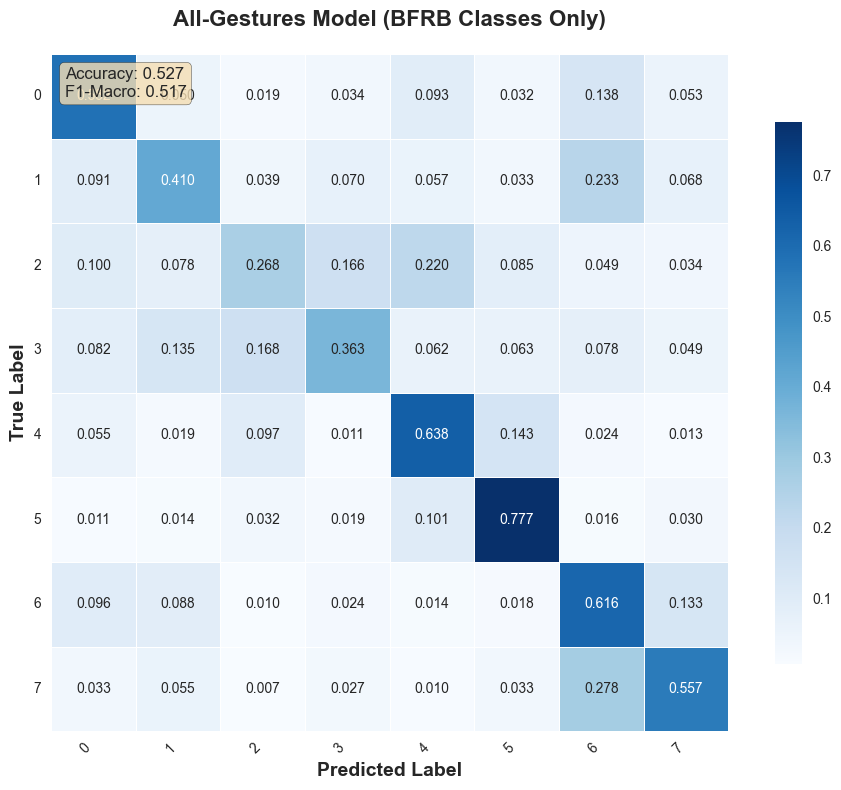

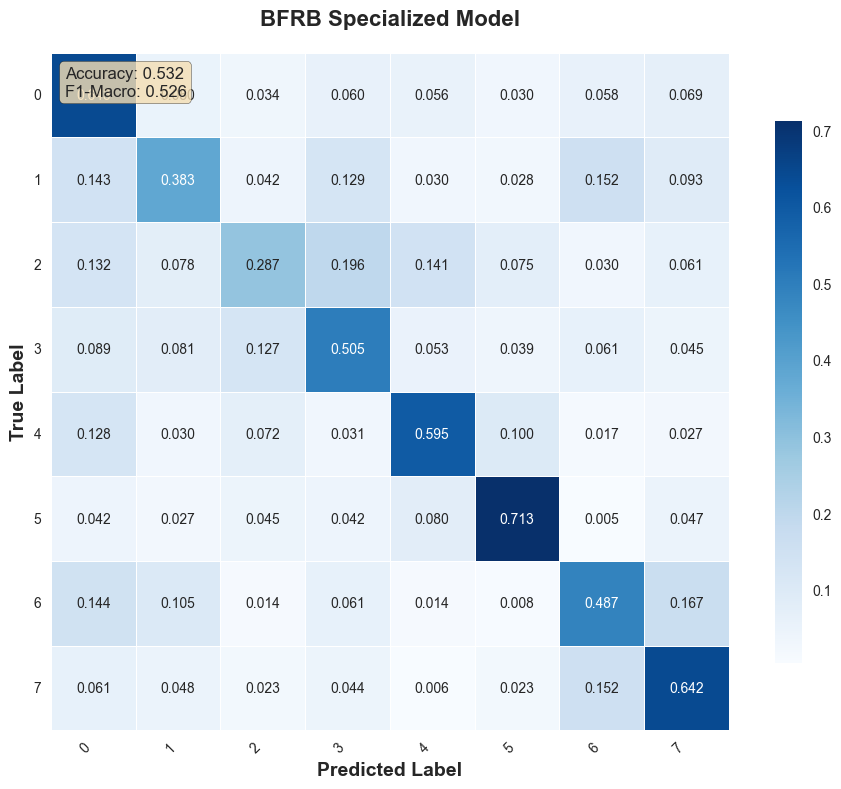

In [22]:
plot_class_performance_comparison(results_all, results_bfrb, all_gesture_classes, bfrb_gesture_classes, config)

In [23]:
# Extract BFRB performance from all-gestures model
bfrb_indices_in_all = [i for i, gesture in enumerate(all_gesture_classes) 
                      if gesture in config.bfrb_gestures]

# Filter predictions for BFRB classes from all-gestures model
all_true_labels = np.array(results_all['true_labels'])
all_predictions = np.array(results_all['predictions'])

bfrb_mask_in_results = np.isin(all_true_labels, bfrb_indices_in_all)
bfrb_true_from_all = all_true_labels[bfrb_mask_in_results]
bfrb_pred_from_all = all_predictions[bfrb_mask_in_results]

# Map indices to BFRB-only scale
bfrb_true_mapped = np.array([bfrb_indices_in_all.index(t) for t in bfrb_true_from_all])
bfrb_pred_mapped = np.array([bfrb_indices_in_all.index(p) if p in bfrb_indices_in_all else -1 
                            for p in bfrb_pred_from_all])

# Remove invalid predictions
valid_mask = bfrb_pred_mapped != -1
bfrb_true_final = bfrb_true_mapped[valid_mask]
bfrb_pred_final = bfrb_pred_mapped[valid_mask]

# Calculate BFRB performance from all-gestures model
bfrb_acc_from_all = np.mean(bfrb_true_final == bfrb_pred_final)
bfrb_f1_from_all = f1_score(bfrb_true_final, bfrb_pred_final, average='macro')

# Comparison table
print(f"\n{'Metric':<25} {'All Gestures':<15} {'BFRB from All':<15} {'BFRB Specialized':<18} {'Improvement':<12}")
print("-" * 85)
print(f"{'Overall Accuracy':<25} {results_all['overall_accuracy']:<15.4f} {bfrb_acc_from_all:<15.4f} {results_bfrb['overall_accuracy']:<18.4f} {results_bfrb['overall_accuracy']/bfrb_acc_from_all:<12.2f}x")
print(f"{'Overall F1-Macro':<25} {results_all['overall_f1_macro']:<15.4f} {bfrb_f1_from_all:<15.4f} {results_bfrb['overall_f1_macro']:<18.4f} {results_bfrb['overall_f1_macro']/bfrb_f1_from_all:<12.2f}x")

print(f"\n=== Key Findings ===")
print(f"• BFRB specialized model achieves {results_bfrb['overall_accuracy']:.4f} accuracy vs {bfrb_acc_from_all:.4f} from all-gestures model")
print(f"• Improvement in BFRB classification: {(results_bfrb['overall_accuracy']/bfrb_acc_from_all - 1)*100:.1f}%")
print(f"• F1-macro improvement: {(results_bfrb['overall_f1_macro']/bfrb_f1_from_all - 1)*100:.1f}%")

if results_bfrb['overall_accuracy'] > bfrb_acc_from_all:
    print(f"✅ HYPOTHESIS CONFIRMED: Specialized BFRB model outperforms general model for BFRB classification")
else:
    print(f"❌ HYPOTHESIS REJECTED: General model performs better or similar for BFRB classification")


Metric                    All Gestures    BFRB from All   BFRB Specialized   Improvement 
-------------------------------------------------------------------------------------
Overall Accuracy          0.6337          0.5267          0.5321             1.01        x
Overall F1-Macro          0.6743          0.5170          0.5237             1.01        x

=== Key Findings ===
• BFRB specialized model achieves 0.5321 accuracy vs 0.5267 from all-gestures model
• Improvement in BFRB classification: 1.0%
• F1-macro improvement: 1.3%
✅ HYPOTHESIS CONFIRMED: Specialized BFRB model outperforms general model for BFRB classification
